## Bibliothèques

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

#### librairie "morta_nuts2" construite

In [2]:
from morta_nuts2.data.eurostat import Eurostat_data, EurostatConfig
from morta_nuts2.data.mortality_table import MortalityCalculator, MortalityConfig
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import lcp_bspline_initialisation, lileep_bspline_initialisation
from morta_nuts2.model.projection.project import project_LC_prospective_SVD,high_age_extrapolation,high_age_extrapolation_snd,project_LeeLi_prospective,compute_life_expectancy_all,compute_life_expectancy_sim,compute_life_expectancy
from morta_nuts2.graph.plot import*

In [3]:
#from morta_nuts2.data.raw_data import*
#from morta_nuts2.data.raw import*
#from morta_nuts2.data.processed import*
from morta_nuts2.model.LC_p.lc_p import LCp_fit, LC_fit, build_input_from_dataframe
#from morta_nuts2.model.LC.lc import
from morta_nuts2.model.LL_p.ll_p import LiLee_p_fit, LandL_fit



### Test fonctions imports de data eurostat

In [4]:

# Option 1: Le chemin par défaut est déjà bon : sans path ils stock dans la data dans le lieu ou se trouve votre script

# Option 2: Changer le chemin par défaut pour toute l'application
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Chargement du shapefile NUTS... NUTS_RG_01M_2024_3035.shp
✅ Shapefile chargé (1798 entités)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [5]:
data_fr = data_brute.load_all("FR")

💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [6]:
#data_fr["deaths"]

In [7]:
#population_fr

In [8]:
#mortality_fr

In [9]:
#df_agg = Dxt_raw.groupby(["geo", "sex", "time"])["values"].sum().reset_index()

### Test fonction renvoyant le nombre de décès, l'exposition et les taux de mortalité brutes par région

In [10]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="M")

2026-02-24 10:09:53,243 - MortalityCalculator - INFO - Chargement du shapefile: C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp
2026-02-24 10:09:53,526 - MortalityCalculator - INFO - 1793 régions chargées
2026-02-24 10:09:53,542 - MortalityCalculator - INFO - MortalityCalculator initialisé avec 1793 régions
2026-02-24 10:09:53,544 - MortalityCalculator - INFO - Validation des données d'entrée...
2026-02-24 10:09:56,486 - MortalityCalculator - INFO - Validation réussie
2026-02-24 10:09:56,487 - root - INFO - validate_input_data exécuté en 2.94 secondes
2026-02-24 10:09:56,524 - MortalityCalculator - INFO - Résultat récupéré du cache
2026-02-24 10:09:56,526 - root - INFO - calculate_mortality exécuté en 2.98 secondes


In [11]:
#table

In [12]:
#données d'entrée modèles
dictio = build_input_from_dataframe(table)
#dictio

In [13]:
#test_table_by_age = mortality_by_region_by_age(mortality_fr,population_fr,deaths_fr,regions)
#test_table_by_age

#### Paramètres

In [14]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3 
n_knots = 10


Shape Dxtg : (83, 34, 22)
Shape Extg : (83, 34, 22)
Shape Muxtg : (83, 34, 22)
Ages : 83
Years : 34
Regions : 22


#### modèle Lee carter classique

In [15]:
nb_iter_LC = 300
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))
# nb parameters
#nb_params_LC = len(ax_init)*2 + len(common_years)
#LC fit
axLC , bxLC, kappaLC , Fit_stat_LC = LC_fit(ax_init,bx_init,kappa_init,Extg,Dxtg,xv,tv,nb_iter_LC)

In [16]:
#Fit_stat_LC

In [17]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))
#number of parameter
h = 0.0          # smoothness
z = 3            # order of difference for smoothness
nb_iterLL = 800
axLL, bxLL , bx_grLL , kappaLL ,kappa_grLL , Fit_stat_LL = LandL_fit(ax_init, 
            bx_init , bx_gr_init ,kappa_init, kappa_gr_init,Extg, Dxtg,Muxtg, 
            xv, tv, nb_iterLL,h,z, verbose=False)

In [18]:
#Fit_stat_LL

#### modèle Lee cater avec Bsplines

In [19]:


# # Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# ax_coef_init = np.zeros(n_basis)
# bx_coef_init =   0.001*np.ones((len(regions), n_basis))
# kappa_init =   np.ones(len(tv))


In [20]:

ax_coef_init, bx_coef_init, kappa_init = lcp_bspline_initialisation(
    Dxtg, Extg, xv, degree, n_knots)



In [21]:
#degree = 3 
#n_knots = 10

# Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# ax_coef_init = np.zeros(n_basis)
# bx_coef_init = np.ones((len(regions), n_basis))
# kappa_init =  np.ones(len(tv))

In [22]:
# degree = 3 
# n_knots = 10

# # Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# ax_coef_init = np.zeros(n_basis)
# bx_coef_init = np.zeros((len(regions), n_basis))
# kappa_init =  np.zeros(len(tv))

In [23]:
result_lcp = LCp_fit(
    ax_coef_init=ax_coef_init,
    bx_coef_init=bx_coef_init,
    kappa_init=kappa_init,
    Extg=Extg,
    Dxtg=Dxtg,
    xv=xv,
    tv=tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    eta0=0.2,
    verbose=True
)




It    0 | lnL = -510167.5706 | Δ = +inf | η = 0.21000
It   10 | lnL = -279435.4441 | Δ = +464.341773 | η = 0.16289
It   20 | lnL = -275739.5607 | Δ = +468.872040 | η = 0.26533
It   30 | lnL = -267727.5025 | Δ = +1131.507287 | η = 0.43219
It   40 | lnL = -253859.7954 | Δ = +1408.284440 | η = 0.70400
It   50 | lnL = -242780.9441 | Δ = +847.316429 | η = 1.14674
It   60 | lnL = -239539.8226 | Δ = -2423.482991 | η = 1.86792
It   70 | lnL = -4370896.3059 | Δ = +5505749.113189 | η = 0.15645
It   80 | lnL = -237343.6558 | Δ = +5810.507360 | η = 0.25484
It   90 | lnL = -228350.2464 | Δ = +107.881937 | η = 0.41511
It  100 | lnL = -227745.6334 | Δ = +43.489931 | η = 0.67617
It  110 | lnL = -227317.9801 | Δ = +44.314040 | η = 1.10140
It  120 | lnL = -227078.7997 | Δ = +8.179309 | η = 0.19372
It  130 | lnL = -226999.7261 | Δ = +9.192640 | η = 0.31555
It  140 | lnL = -226886.4546 | Δ = +13.195893 | η = 0.51400
It  150 | lnL = -226730.2853 | Δ = +17.565460 | η = 0.83726
It  160 | lnL = -226558.5061 |

In [24]:
result_lcp['fit_statistics']

,N,n_basis,dofs,lnL,deviance,AIC,BIC
0,62084,12,310,-225375.29,-84659842.36,451370.59,454171.82


### modèle Lee and Li avec B-splines .....

In [25]:
# degree = 3  
# n_knots = 10

# # Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# alpha_coef_init = np.ones((nb_regions, n_basis))
# beta_coef_init = np.ones(n_basis)
# beta_g_coef_init = np.ones((nb_regions, n_basis))

# kappa_init = np.ones(nb_years)
# kappa_g_init = np.ones((nb_regions, nb_years))


In [26]:
#print(np.max(np.abs(kappa_init)))
#print(np.max(np.abs(kappa_g_init)))


In [27]:
(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init
) = lileep_bspline_initialisation(
        Dxtg,
        Extg,
        xv,
        degree,
        n_knots
)


In [28]:
resultat_llp = LiLee_p_fit(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init,
    Extg,
    Dxtg,
    xv,
    tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    tol=1e-6,
    verbose=True
)


CALIBRATION MODÈLE LI-LEE PARAMÉTRIQUE
Paramètres : degree=3, n_knots=10, lam=2
Données : 83 âges × 34 années × 22 régions
Nombre de fonctions de base : 12
It    0 | lnL = -577,166.17 | Δ = -577166.169189 | η = 0.15000
It   10 | lnL = -223,438.19 | Δ = +1362.236693 | η = 0.11635
It   20 | lnL = -219,336.48 | Δ = +134.199080 | η = 0.18952
It   30 | lnL = -218,352.64 | Δ = +91.533672 | η = 0.30871
It   40 | lnL = -217,742.49 | Δ = +46.212302 | η = 0.50286
It   50 | lnL = -217,397.07 | Δ = +27.447217 | η = 0.81910
It   60 | lnL = -245,985.08 | Δ = -22434.606866 | η = 0.30255
It   70 | lnL = -217,414.92 | Δ = +32.020172 | η = 0.23467
It   80 | lnL = -217,063.20 | Δ = +35.959937 | η = 0.38226
It   90 | lnL = -216,748.61 | Δ = +26.541053 | η = 0.62266
It  100 | lnL = -216,533.72 | Δ = +18.862669 | η = 1.01425
It  110 | lnL = -216,354.35 | Δ = +15.934401 | η = 1.65210
It  120 | lnL = -224,472.78 | Δ = +3488.621658 | η = 0.29058
It  130 | lnL = -219,405.49 | Δ = +96.678528 | η = 0.47333
It  14

In [28]:
#resultat_llp["fit_statistics"]

In [29]:
mu_obs = Dxtg / Extg
curves = {
    "Observed": mu_obs,
    #"LC": mu_hat_lc,
    "LC_p": result_lcp["fitted_values"]["mu"],
    "LL_p": resultat_llp["fitted_values"]["mu"]}





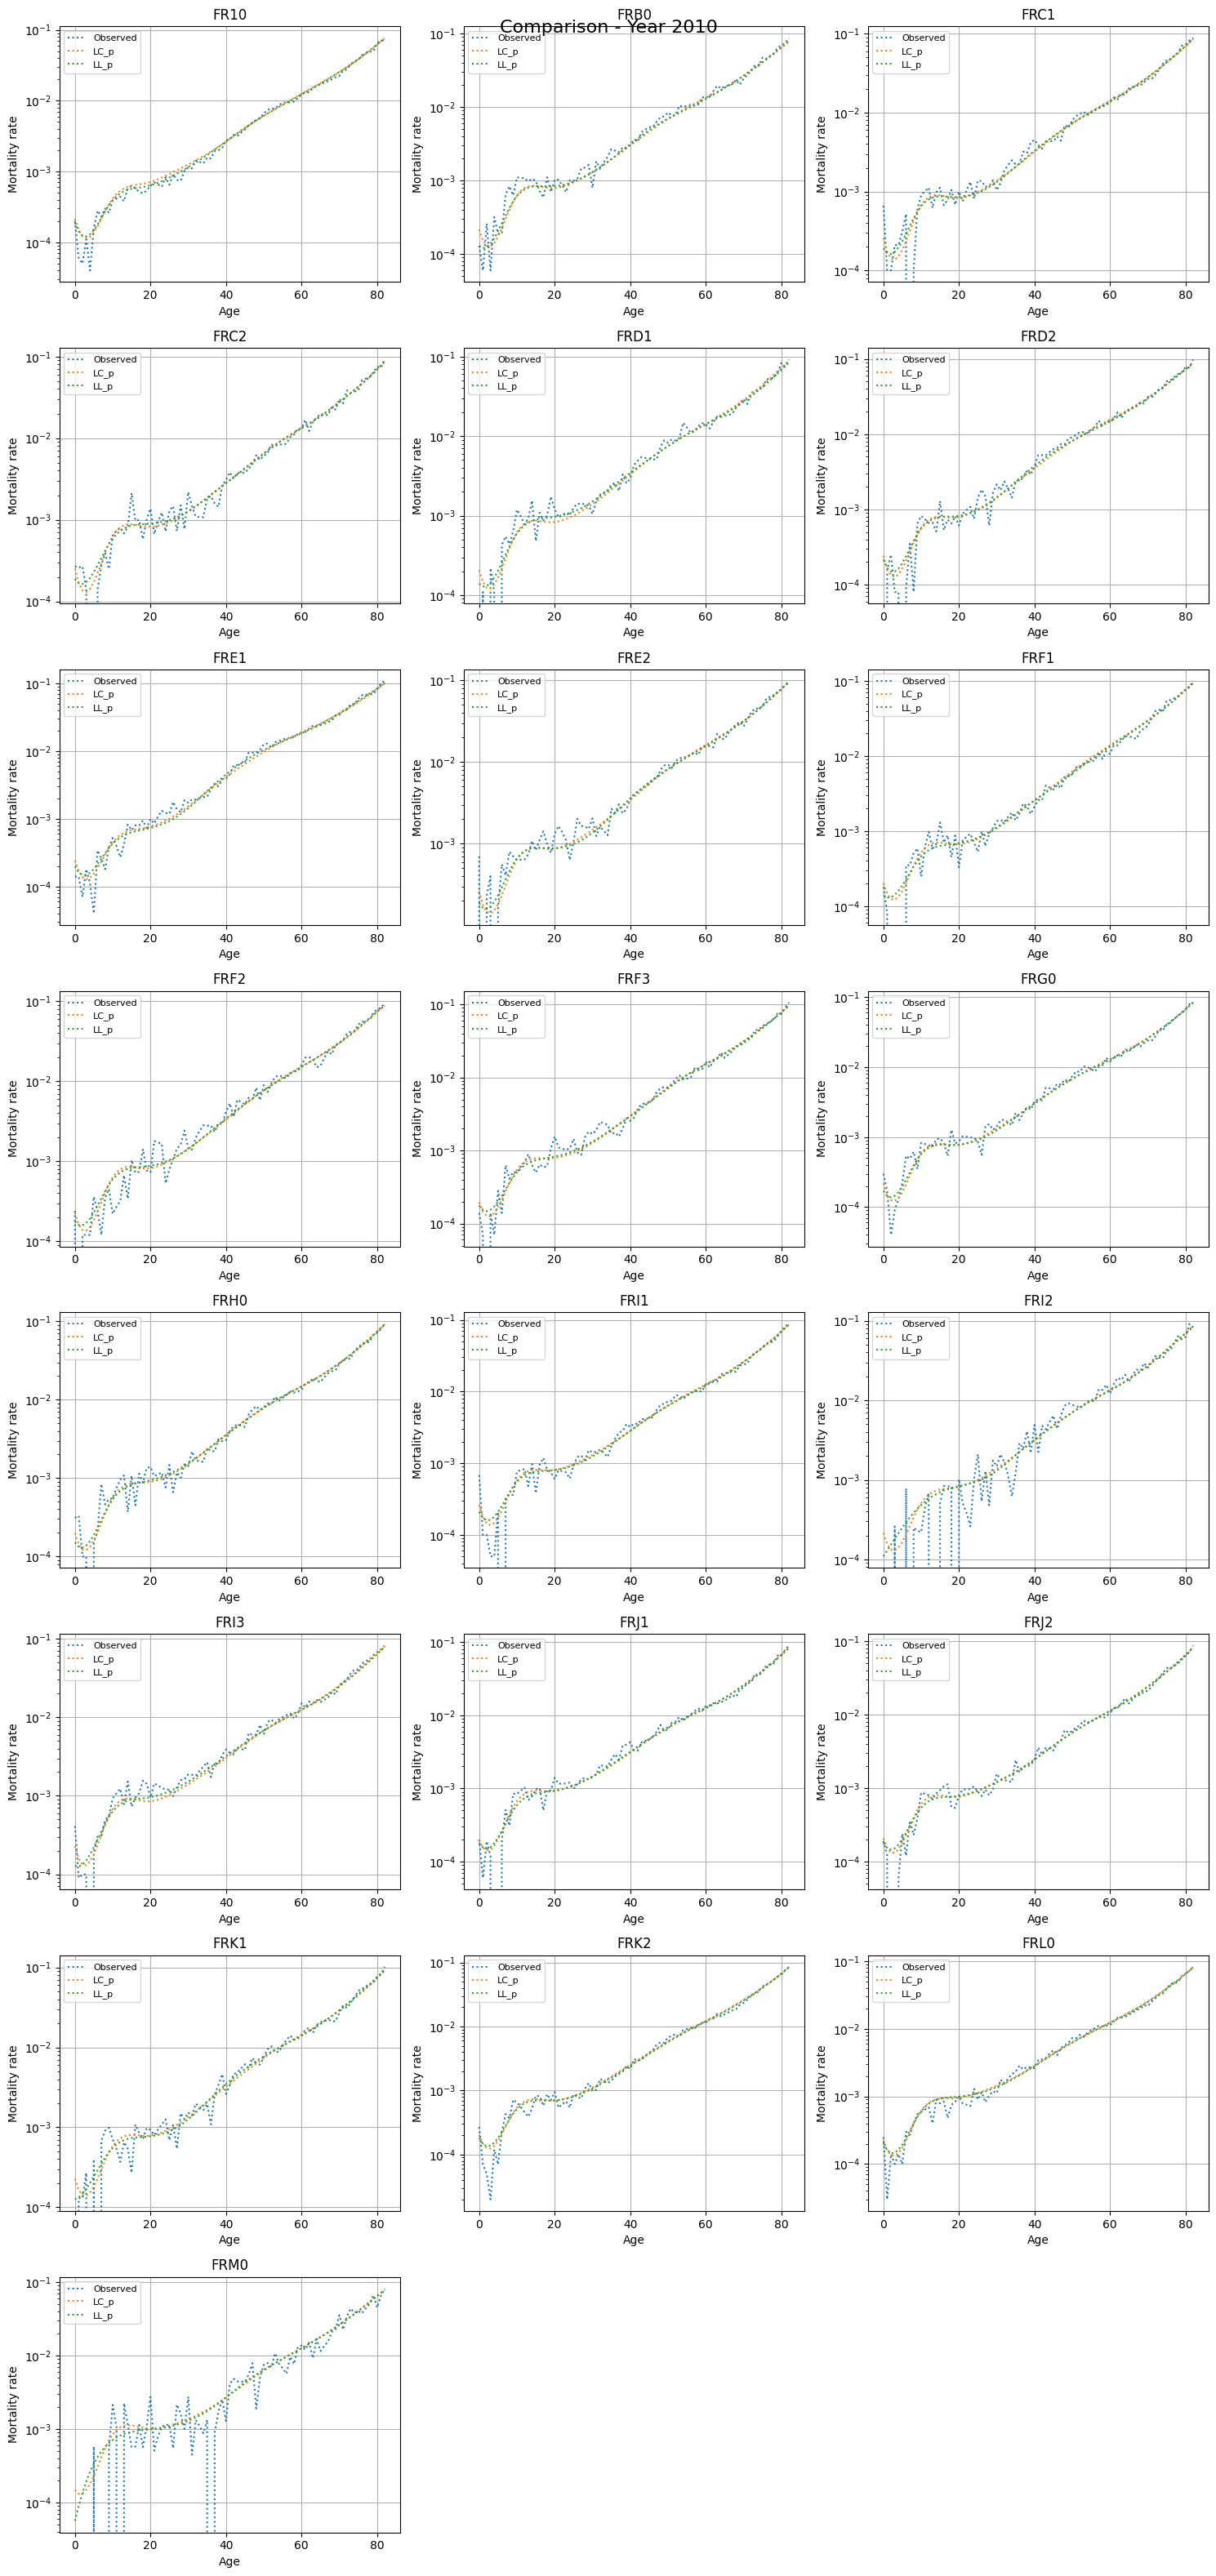

In [30]:
plot_models_by_region(
                    x_values=xv,
                    curves_dict=curves,
                    year_to_plot=2010,
                    tv=tv,
                    regions=regions)

### Projection des taux et extrapolation

##### Lee carter

In [31]:
proj_sto = project_LC_prospective_SVD(
    result_lcp,
    tv,
    horizon=27,
    nb_components=1,
    exclude_years=[2020,2021],
    stochastic=False,
    n_sim=5000,
    model="rw"
    )


In [32]:
# proj_sto_1 = project_LC_prospective_SVD(
#     result_lcp,
#     tv,
#     horizon=27,
#     nb_components=1,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw"
    
# )

##### Lee and Li

In [33]:
proj_leeandli = project_LeeLi_prospective( resultat_llp,
    tv,
    horizon=27,
    exclude_years=[2020,2021],
    stochastic=False,
    n_sim=5000,
    model="rw")

In [34]:
# proj_leeandli = project_LeeLi_prospective( resultat_llp,
#     tv,
#     horizon=27,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw")

##### Extrapolation

In [36]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_lcp, xv_full = high_age_extrapolation(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 80,        # début de la fenêtre de régression commencer à 60 ans 
    log_Muxtg   = proj_sto['logmu_future'])

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_lcp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 22, 27)
Grille d'âges    : [  0 110]


In [ ]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = high_age_extrapolation(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = 80,        # début de la fenêtre de régression
                    log_Muxtg   = proj_leeandli["logmu_future"]
                )
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 22, 27)
Grille d'âges    : [  0 110]


In [ ]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_lcp_hist, xv_full = high_age_extrapolation(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 80,        # début de la fenêtre de régression
    log_Muxtg   = result_lcp["fitted_values"]["log_mu"]
)
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_lcp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [ ]:
logmu_llp_hist, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 80,        # début de la fenêtre de régression
    log_Muxtg   = resultat_llp["fitted_values"]["log_mu"]
)
# logmu_extrap → (111, 3, 30, 500)
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)   # (111, 3, 30, 500)
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [41]:
logmu_full_lcp = np.concatenate([logmu_lcp_hist, np.transpose(logmu_extrap_lcp,(0, 2, 1))], axis=1)
print("log-mu lcp extrapolé :", logmu_full_lcp.shape) 

log-mu lcp extrapolé : (111, 61, 22)


In [ ]:
logmu_full_llp = np.concatenate([logmu_llp_hist, np.transpose(logmu_extrap_lcp,(0, 2, 1))], axis=1)
print("log-mu llp extrapolé :", logmu_full_llp.shape)

log-mu lcp extrapolé : (111, 61, 22)


In [ ]:
# def compute_life_expectancy_all(mu_future):
#     """
#     mu_future : (ages, horizon, regions)
#     retourne  : (ages, horizon, regions)
#     """
#     ages, horizon, regions = mu_future.shape
#     ex = np.zeros((ages, horizon, regions))

#     for r in range(regions):
#         for t in range(horizon):

#             mu = mu_future[:, t, r]          # ✅ axis=1 → horizon, axis=2 → regions
#             qx = np.clip(mu / (1 + 0.5 * mu), 0, 1)

#             lx      = np.zeros(ages)
#             lx[0]   = 100000
#             lx[1:]  = lx[0] * np.cumprod(1 - qx[:-1])

#             Lx      = np.zeros(ages)
#             Lx[:-1] = 0.5 * (lx[:-1] + lx[1:])
#             Lx[-1]  = lx[-1]

#             Tx         = np.flip(np.cumsum(np.flip(Lx)))
#             ex[:, t, r] = Tx / lx             # ✅ cohérent avec (ages, horizon, regions)

#     return ex

In [43]:
esp_vie_lcp = compute_life_expectancy_all(np.exp(logmu_full_lcp))

C:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\src\morta_nuts2\model\projection\project.py:26: RuntimeWarning: invalid value encountered in divide
  ex[:, t, r] = Tx / lx             # ✅ cohérent avec (ages, horizon, regions)


In [45]:
esp_vie_llp = compute_life_expectancy_all(np.exp(logmu_full_llp))

#### Visualisation graphique

In [46]:
#Paramètre
tv_future = np.arange(1990, 2023 + 28) #années

In [47]:
# # e₀ (age=0)
# t#v_future = np.arange(1990, 2023 + 28)
# plot_map_indicator(
#     regions        = regions,
#     data           = esp_vie_lcp,            # (111, horizon, 22)
#     tv_future      = tv_future,
#     country_code   = "FR",
#     indicator_name = "Espérance de vie",
#     year           = 2050,
#     age            = 0,             # ← e₀
# )


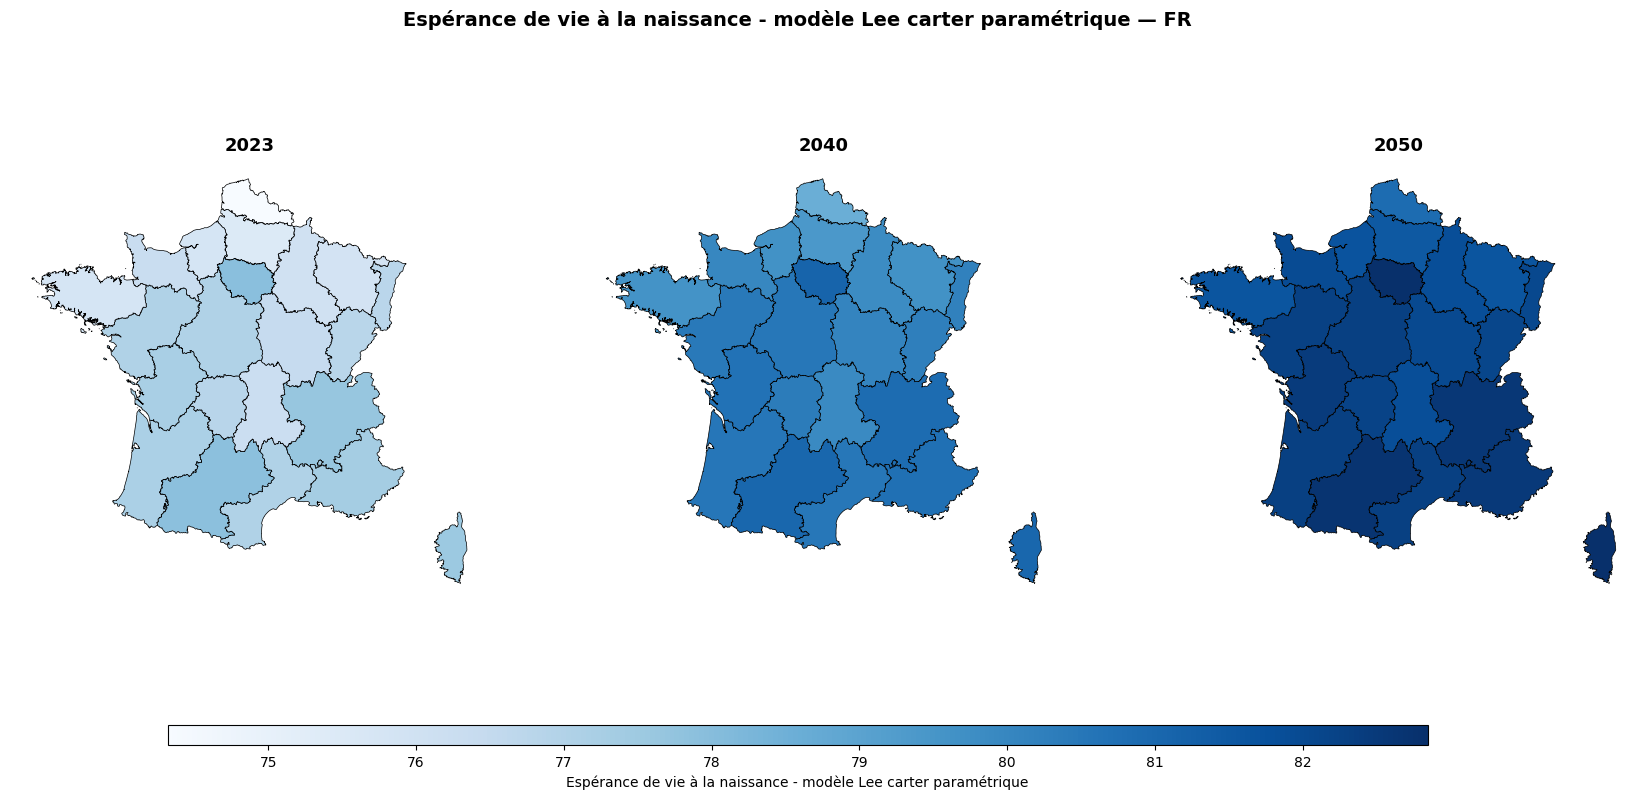

In [51]:
plot_map_compare_years(
    regions=regions, data=esp_vie_lcp,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee carter paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

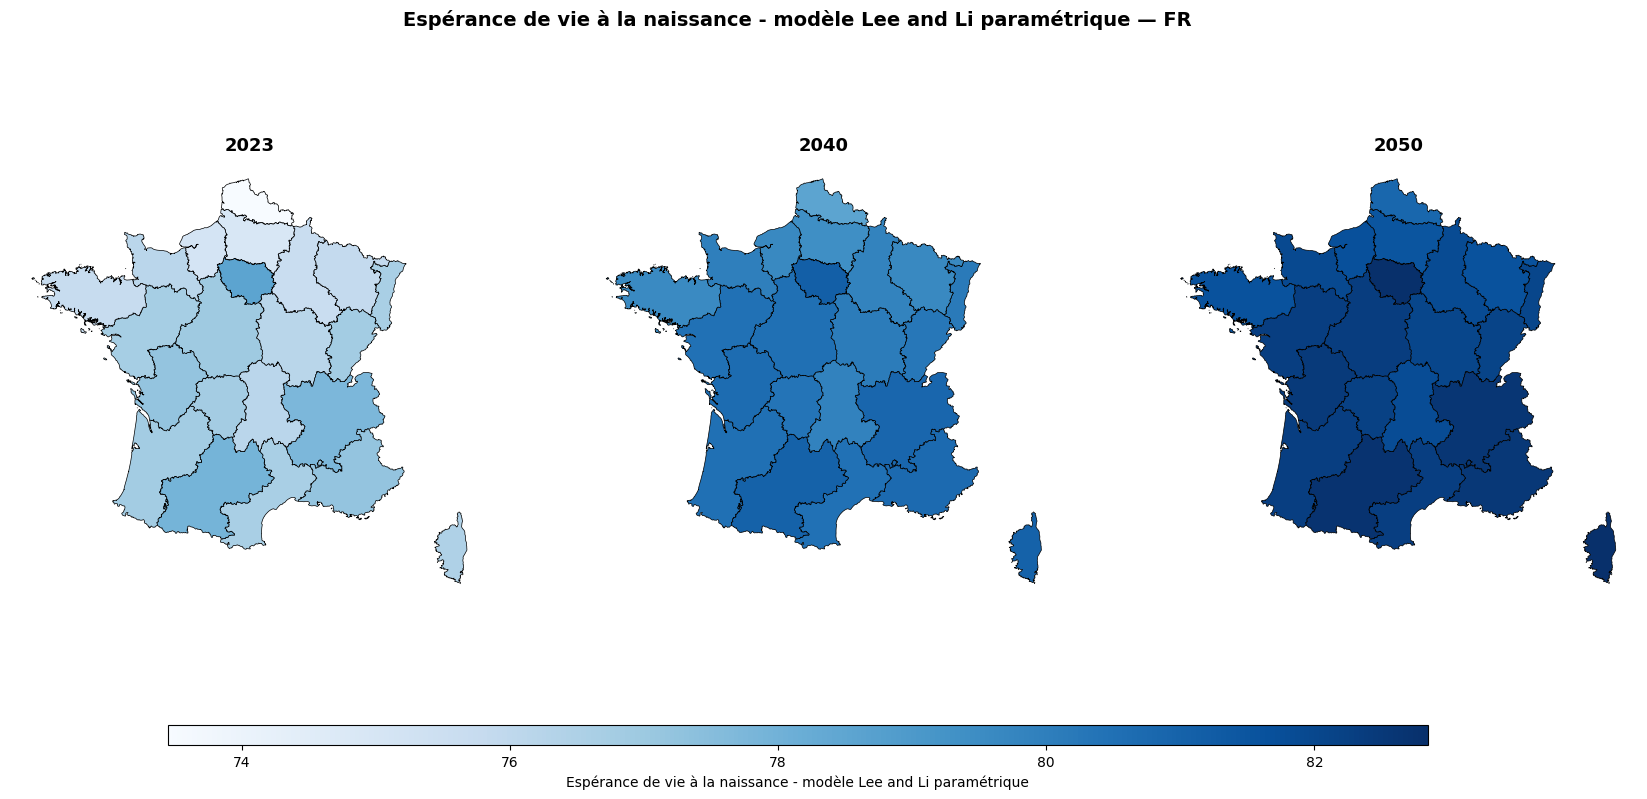

In [52]:
plot_map_compare_years(
    regions=regions, data=esp_vie_llp,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee and Li paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

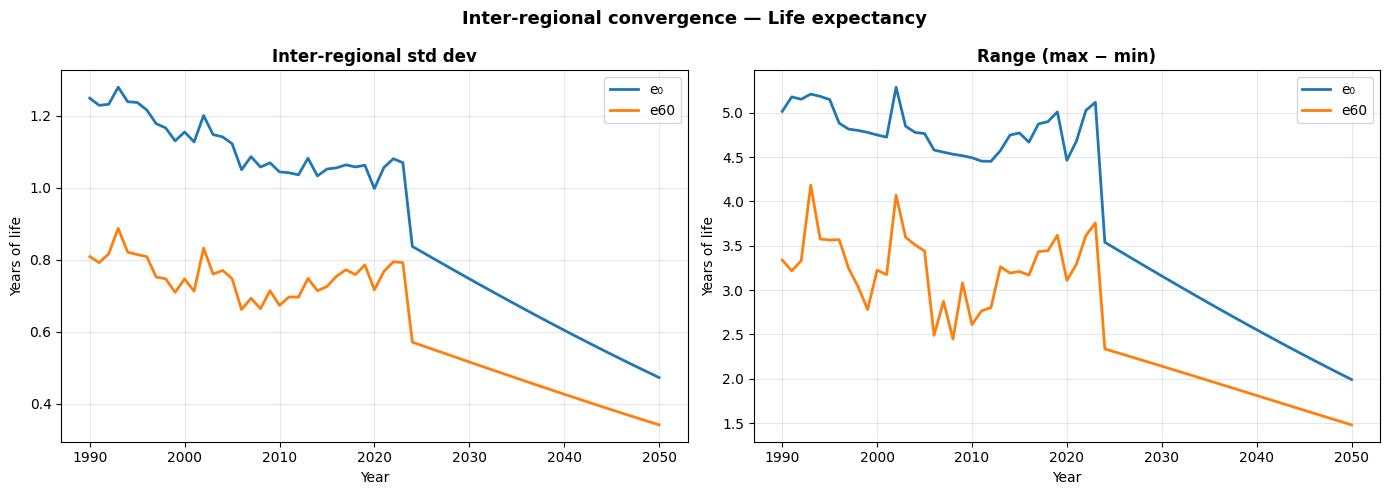

In [56]:
# 3. Convergence inter-régionale
plot_dispersion_over_time(
    ex        = esp_vie_llp,
    regions   = regions,
    tv_future = tv_future,
    ages      = [0, 60],
)

In [53]:
# #  Stats régionales
# stats = compute_regional_stats(esp_vie, regions, tv_future, age=0)
# print(stats["by_year"].head())      # stats par année
# print(stats["by_region"])           # classement régions



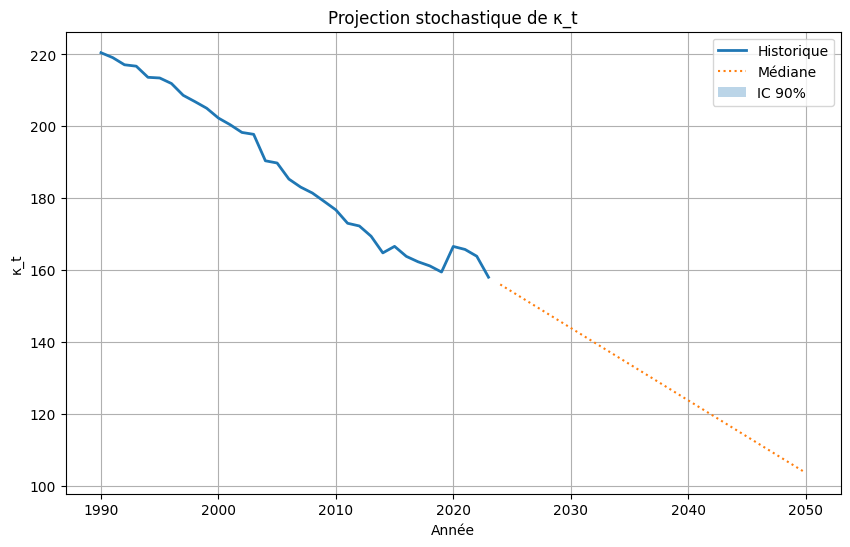

In [ ]:
# #visualisation Kappaa

# def plot_kappa_stochastic(tv, kappa_hist, kappa_paths):
    
#     horizon, n_sim = kappa_paths.shape
#     future_years = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    
#     kappa_lower = np.percentile(kappa_paths, 5, axis=1)
#     kappa_median = np.percentile(kappa_paths, 50, axis=1)
#     kappa_upper = np.percentile(kappa_paths, 95, axis=1)
#     kappa_proje = kappa_paths
#     plt.figure(figsize=(10,6))
    
#     plt.plot(tv, kappa_hist, label="Historique", linewidth=2)
    
#     plt.plot(future_years, kappa_paths, label="Médiane", linestyle=":")
#     plt.fill_between(
#         future_years,
#         kappa_lower,
#         kappa_upper,
#         alpha=0.3,
#         label="IC 90%"
#     )
    
#     #plt.axvline(tv[-1], color="black", linestyle=":")
    
#     plt.title("Projection stochastique de κ_t")
#     plt.xlabel("Année")
#     plt.ylabel("κ_t")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# plot_kappa_stochastic(tv,result_lcp['parameters']["kappa"],proj_sto["kappa_future"])

### Annexes

In [51]:
shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_mxt_raw_FR.csv  (1,543,872 lignes)
[Eurostat] Chargé depuis cache → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Dxt_raw_FR.csv  (231,132 lignes)
[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Lxt_raw_FR.csv  (244,728 lignes)
